In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
# code_dir = f'{os.getenv('HOME')}/cai-dr2-clustering-products/clustering_statistics/'
sys.path.insert(0,'../')
import tools
import plotting_tools
import box_tools

In [3]:
analysis = 'full_shape'
project = f'{analysis}/base'
region  = 'GCcomb'
tracers = ['LRG']
zranges = [(0.6,0.8)] 
weight = 'default-FKP'
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))

ells4pk = [0,2]
ells4xi = [0,2]
ells4bk = [(0,0,0), (2,0,2)]

In [4]:
plot_dir = Path('_plots_desi_meeting')
plot_dir.mkdir(exist_ok=True)
for tracer in tracers:
    sub_directory = plot_dir / tracer
    sub_directory.mkdir(exist_ok=True)
ext = 'png'

In [5]:
# get mock indices to use for mock covariance estimation
glam_imocks = np.loadtxt('../helper_scripts/glam-uchuu-v2-altmtl_dark-time_imocks_for_covariance_v2.txt',dtype=int)
holi_imocks = np.loadtxt('../helper_scripts/holi-v3-altmtl_dark-time_imocks_for_covariance_v2.txt',dtype=int)
print(len(glam_imocks),len(holi_imocks))

1007 847


In [6]:
# measumerents to compare
reference = 'glam-uchuu-v2-altmtl' # what we compare against in the figures below
cases = {
    'glam-uchuu-v2-altmtl': {'version': 'glam-uchuu-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': glam_imocks},
    'holi-v3-altmtl': {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': holi_imocks},
    'abacus-hf-dr2-v2-altmtl': {'version': 'abacus-hf-dr2-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
    'uchuu-hf-altmtl':   {'version': 'uchuu-hf-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': None},
        }
# colors and linestyles
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':',':']))

# Clustering statistics: power spectra, bispectra, and two-point correlation function (2PCF).

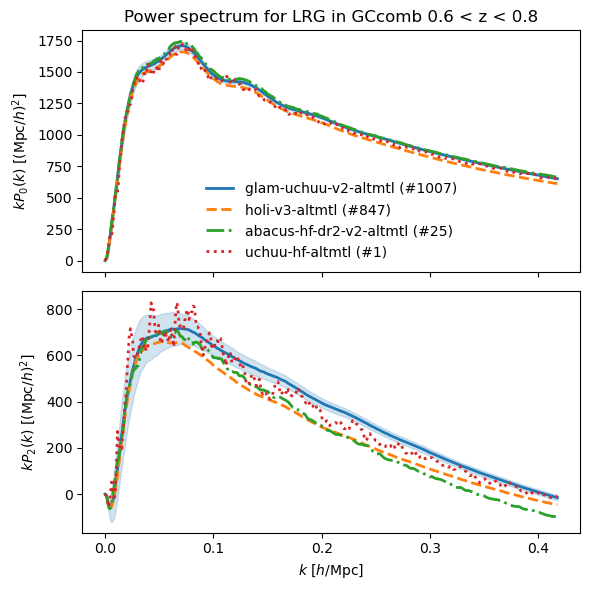


CPU times: user 21.7 s, sys: 2.5 s, total: 24.2 s
Wall time: 27 s


In [13]:
%%time
# figures with power spectra
scaling='kpk'
# scaling='loglog'

plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,legend_ncol=1)
for tracer in tracers:
    # zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    # nrows  = len(ells4pk) * 2
    # ncols  = len(zranges)
    # figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
    nrows  = len(ells4pk)
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * len(ells4pk)), sharex='col')
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4pk)
        title = f'Power spectrum for {tracer} in {region} {zrange[0]:.1f} < z < {zrange[1]:.1f}'
        plotting_tools.plot_stats('mesh2_spectrum', cases, tracer, zrange, region, title=title, **plot_kws)
    plt.tight_layout()
    basename = f'pk_{tracer}_{region}.{ext}'
    figure[0].savefig(plot_dir / tracer / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()
    print()

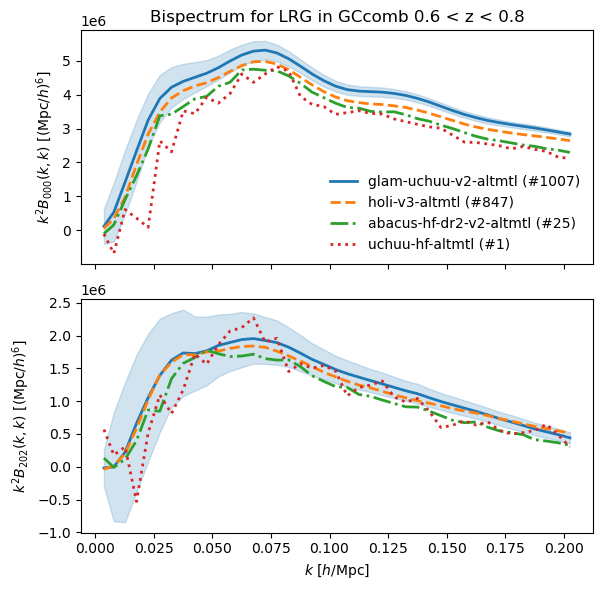

CPU times: user 17.5 s, sys: 2.51 s, total: 20.1 s
Wall time: 1min 14s


In [14]:
%%time
# figures with bispectra
scaling='kpk'
# scaling='loglog'

plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project)
for tracer in tracers:
    # zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    # nrows  = len(ells4bk) * 2
    # ncols  = len(zranges)
    # figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4bk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4bk)})
    nrows  = len(ells4bk)
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * len(ells4bk)), sharex='col')
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4bk)
        title = f'Bispectrum for {tracer} in {region} {zrange[0]:.1f} < z < {zrange[1]:.1f}'
        plotting_tools.plot_stats('mesh3_spectrum_sugiyama-diagonal', cases, tracer, zrange, region, title=title, **plot_kws)
    plt.tight_layout()
    basename = f'bk_{tracer}_{region}.{ext}'
    figure[0].savefig(plot_dir / tracer / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

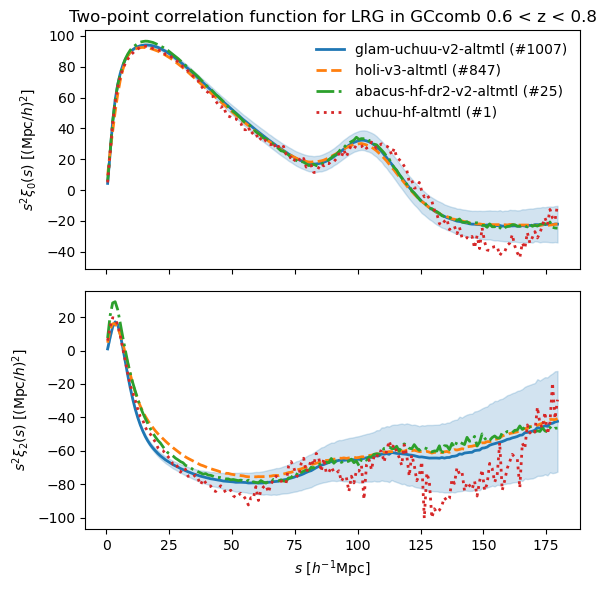

CPU times: user 30.4 s, sys: 4.57 s, total: 34.9 s
Wall time: 37.8 s


In [16]:
%%time
# figures with 2PCF
plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,legend_ncol=1)
for tracer in tracers:
    # zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    # nrows  = len(ells4xi) * 2
    # ncols  = len(zranges)
    # figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4xi)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4xi)})
    nrows  = len(ells4xi)
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * len(ells4xi)), sharex='col')
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4xi)
        title = f'Two-point correlation function for {tracer} in {region} {zrange[0]:.1f} < z < {zrange[1]:.1f}'
        plotting_tools.plot_stats('particle2_correlation', cases, tracer, zrange, region, title=title, **plot_kws)
    plt.tight_layout()
    basename = f'xi_{tracer}_{region}.{ext}'
    figure[0].savefig(plot_dir / tracer / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

# Covariances

In [28]:
def plot_covariance_diag(kind, ref_imock, imocks, versions, reference, ells=[0,2], save_diag_fn=None, **stats_kws):
    # get analytical covariance
    if 'mesh2_spectrum' in kind:
        fn = tools.get_stats_fn(**stats_kws, version=reference, kind=f'covariance_{kind}', imock=ref_imock[reference])
        print(fn)
        covariance_analytic = types.read(fn).at.observable.get(observables='spectrum2', tracers=(tools.get_simple_tracer(tracer),) * 2)
    elif 'particle2_correlation' in kind:
        fn = tools.get_stats_fn(**(stats_kws | dict(project='full_shape/analytic_covariance_validation')), version='holi-v3-altmtl',
                                kind='covariance_particle2_correlation', battrs=['poles'], imock=0)
        covariance_analytic = types.read(fn).at.observable.get(observables='correlation2', tracers=(tools.get_simple_tracer(tracer),) * 2)
    
    # get covariance from mocks
    cov_mocks = {}
    for version in versions:
        if isinstance(imocks,str): # when imocks='*' 
            fns = tools.get_stats_fn(**stats_kws, version=version, kind=kind, imock=imocks[version])
        else:
            fns = [tools.get_stats_fn(**stats_kws, version=version, kind=kind, imock=imock) for imock in imocks[version]]
        # fns   = [fn for fn in fns if os.path.exists(fn)] 
        if 'mesh' in kind:
            mocks = [types.read(fn) for fn in fns]
        else:
            mocks = [types.read(fn).project(ells=ells) for fn in fns]
        # sns   = [mock.get(ells=ells[0]).values('shotnoise').mean() for mock in mocks]
        # print(f'Shotnoise is {np.mean(sns):.0f}+-{np.std(sns):.0f}')
        cov_mocks[version] = types.cov(mocks)
    
    # match covariances
    if 'mesh2_spectrum' in kind:
        observable = cov_mocks[reference].observable.select(k=slice(0, None, 5)).select(k=(0., 0.2)).get(ells=list(ells))
        covariance_analytic = covariance_analytic.at.observable.match(observable)
    elif 'mesh3_spectrum' in kind:
        observable = cov_mocks[reference].observable
    elif 'particle2_correlation' in kind:
        observable = covariance_analytic.observable.select(s=slice(0, None, 4)).select(s=(40., 180.)).get(ells=list(ells))
        covariance_analytic = covariance_analytic.at.observable.match(observable)
    for version in versions:
        cov_mocks[version] = cov_mocks[version].at.observable.match(observable)
    # print(observable.get(ells=ells[0]).coords('k')[...,0])
    # print(observable.get(ells=ells[0]).edges('k')[...,0])
    
    # now plot
    if 'mesh2_spectrum' in kind: 
        kw = dict(ytransform=lambda x, y: x**4 * y, offset=np.arange(1))
        fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
        for i, version in enumerate(versions):
            cov_mocks[version].plot_diag(**kw, fig=fig, color=f'C{i+1}', show=False)
    elif 'mesh3_spectrum' in kind:
        kw = dict(ytransform=lambda x, y: x**6 * y, offset=np.arange(1))
        fig = cov_mocks[versions[0]].plot_diag(**kw, show=False, color='C1')
        for i, version in enumerate(versions[1:]):
            cov_mocks[version].plot_diag(**kw, fig=fig, color=f'C{i+2}', show=False)
    elif 'particle2_correlation' in kind: 
        kw = dict(ytransform=lambda x, y: x**2 * y, offset=np.arange(1))
        fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
        for i, version in enumerate(versions):
            cov_mocks[version].plot_diag(**kw, fig=fig, color=f'C{i+1}', show=False)
    
    # set title and legend labels
    base_title = f"{stats_kws['tracer']} {stats_kws['region']} {stats_kws['zrange'][0]:.1f} < z < {stats_kws['zrange'][1]:.1f}"
    if 'mesh2_spectrum' in kind:
        fig.suptitle(f'Power spectrum covariance of {base_title}', fontsize=12)
    elif 'mesh3_spectrum' in kind:
        fig.suptitle(f'Bispectrum covariance of {base_title}', fontsize=12)
    elif 'particle2_correlation' in kind: 
        fig.suptitle(f'Correlation function covariance of {base_title}', fontsize=12)
        
    # Handle axis labels
    ncols = len(ells)
    for ax in fig.axes[::ncols]:
        if 'mesh2_spectrum' in kind:
            ax.set_ylabel(r"$k^4\,\mathrm{Cov}$", fontsize=12)
        elif 'mesh3_spectrum' in kind:
            ax.set_ylabel(r"$k^6\,\mathrm{Cov}$", fontsize=12)
        elif 'particle2_correlation' in kind: 
            ax.set_ylabel(r"$k^2\,\mathrm{Cov}$", fontsize=12)
        
        for ax in fig.axes[-ncols:]:
            if 'mesh2' in kind:
            # for now only on Pk, since the ticklabels for Bk do not corresponf to k.
                ax.set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
            elif 'particle' in kind:
                ax.set_xlabel(r'$s$ [$h^{-1}\mathrm{Mpc}$]', fontsize=12)
                
    # set legend
    ax0 = fig.axes[0]
    lines = ax0.get_lines()
    if 'mesh2_spectrum' in kind:
        labels = ['analytic']+versions
    elif 'particle2_correlation' in kind: 
        labels = ['RascalC']+versions
    else:
        labels = versions
    
    ax0.legend(handles=lines, labels=labels)
    fig.set_size_inches(4,4)
    plt.tight_layout()
    
    # save figure 
    fig.savefig(save_diag_fn, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

In [29]:
ref_imock = {'holi-v4-altmtl': 0, 'holi-v3-altmtl': 0, 'abacus-hf-dr2-v2-altmtl': 0, 'glam-uchuu-v2-altmtl': 150} # imock where covariance and windows are saved to
imocks = {'holi-v4-altmtl': '*', 'holi-v3-altmtl': holi_imocks, 'abacus-hf-dr2-v2-altmtl': np.arange(25), 'glam-uchuu-v2-altmtl': glam_imocks}
ells4pk = [0]
ells4xi = [0,2]
ells4bk = [(0,0,0), (2,0,2)]

/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/glam-uchuu-v2-altmtl/mock150/covariance_mesh2_spectrum_poles_LRG_z0.6-0.8_GCcomb_weight-default-FKP.h5


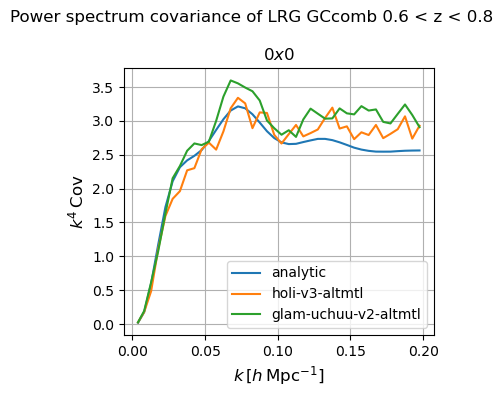


CPU times: user 20.5 s, sys: 2.09 s, total: 22.6 s
Wall time: 24.3 s


In [30]:
%%time
# plot diagonal of the covariance 
versions = ['holi-v3-altmtl', 'glam-uchuu-v2-altmtl']#, 'abacus-hf-dr2-v2-altmtl']
# kinds = ['particle2_correlation','mesh2_spectrum','mesh3_spectrum']
kinds = ['mesh2_spectrum']
for kind in kinds:
    for tracer in tracers:
        # zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
        for iz, zrange in enumerate(zranges): 
            stats_kws = dict(stats_dir=stats_dir, tracer=tracer, project=project, zrange=zrange, region=region, weight=weight, basis='sugiyama-diagonal')
            basename = f'{tracer}_{region}_z{zrange[0]}-{zrange[-1]}.{ext}'
            sub_dir = plot_dir / tracer 
            if 'mesh2' in kind: 
                save_kws = dict(save_diag_fn=sub_dir / f'covpk_diagonal_{basename}')
                ells = ells4pk
            elif 'mesh3' in kind: 
                save_kws = dict(save_diag_fn=sub_dir / f'covbk_diagonal_{basename}')
                ells = ells4bk
            elif 'particle2' in kind:
                save_kws = dict(save_diag_fn=sub_dir / f'covxi_diagonal_{basename}')
                ells = ells4xi   
            plot_covariance_diag(kind, ref_imock, imocks, versions, reference, ells=ells, **save_kws, **stats_kws)
            print()

# Window matrix validation
from https://github.com/cosmodesi/desi-clustering/blob/main/clustering_statistics/nb/validation_window_function_mesh.ipynb

In [25]:
ref_imock = {'holi-v4-altmtl': 0, 'holi-v3-altmtl': 0, 'abacus-hf-dr2-v2-altmtl': 0, 'glam-uchuu-v2-altmtl': 150} # imock where covariance and windows are saved to
imocks = {'holi-v4-altmtl': '*', 'holi-v3-altmtl': holi_imocks, 'abacus-hf-dr2-v2-altmtl': np.arange(25), 'glam-uchuu-v2-altmtl': glam_imocks}
ells4pk = [0]
ells4bk = [(0,0,0)]

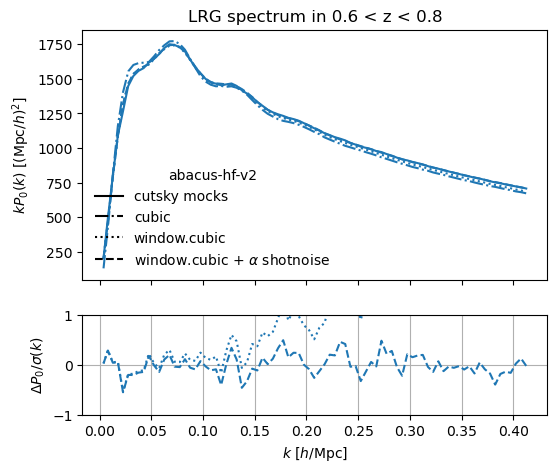

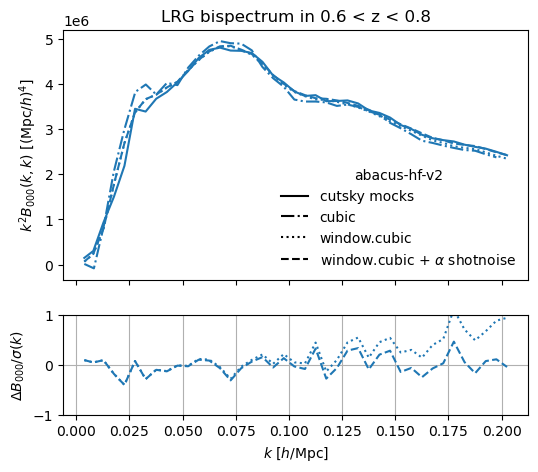

In [28]:
kinds = ['mesh2_spectrum','mesh3_spectrum']
for tracer in tracers:
    # for zrange in tools.propose_fiducial('zranges', tracer):
    for zrange in zranges:
        for kind in kinds:
            nmocks = 25
            zsnap = box_tools.get_zsnap_from_z(tracer, zrange, version='abacus-hf-v2')
            stracer = tools.get_simple_tracer(tracer)
            stats_dir = tools.base_stats_dir
            hod = {'LRG': 'base_B', 'ELG': 'base_conf_nfwexp', 'QSO': 'base'}[stracer]
            fns = [box_tools.get_box_stats_fn(stats_dir=stats_dir, project='full_shape/box_window_function_validation', kind=kind, version='abacus-hf-v2', tracer=stracer,
                                              zsnap=zsnap, cosmo='000', hod=hod, los='z', basis='sugiyama', imock=imock) for imock in range(nmocks)]
            mocks_box = [types.read(fn) for fn in fns if fn.exists()]
            mean_box = types.mean(mocks_box)
            onthefly = 'complete'
            ftracer = tools.get_full_tracer(tracer, version='abacus-hf-dr2-v2-altmtl')
            fns = [tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=kind, version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra=onthefly, imock=imock) for imock in range(nmocks)]
            mocks_cutsky = [types.read(fn) for fn in fns if fn.exists()]
            mean_cutsky = types.mean(mocks_cutsky).select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
    
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version='holi-v3-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.match(mean_cutsky)
    
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind}', version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                    zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra=onthefly, imock=0)
            window_cutsky = types.read(fn).at.observable.match(mean_cutsky)
            mean_box_interp = []
            for label, pole in window_cutsky.theory.items():
                pole_box = mean_box.get(ells=label['ells'])
                if 'mesh3' in kind:
                    pole_box = pole_box.unravel()
                    from scipy import interpolate
                    mask1, mask2 = [np.any(pole_box.values('nmodes') > 0, axis=axis) for axis in [1, 0]]
                    spline = interpolate.RectBivariateSpline(pole_box.coords('k1')[mask1], pole_box.coords('k2')[mask2], pole_box.value()[np.ix_(mask1, mask2)], kx=1, ky=1, s=0)
                    pole = spline(*pole.coords('k').T, grid=False)
                else:
                    mask = pole_box.values('nmodes') > 0
                    pole = np.interp(pole.coords('k'), pole_box.coords('k')[mask], pole_box.value()[mask])
                mean_box_interp.append(pole)
            mean_box_interp = window_cutsky.theory.clone(value=np.concatenate(mean_box_interp))
            mean_box_conv = window_cutsky.dot(mean_box_interp, return_type=None)
            
            shotnoise = window_cutsky.theory.clone(value=0. * window_cutsky.theory.value()).value(concatenate=False)
            shotnoise[0] += next(iter(mean_cutsky)).values('shotnoise').mean()
            shotnoise = window_cutsky.dot(np.concatenate(shotnoise), return_type='nparray')[None, ...]
            precision = np.diag(1. / cov.std())
            # Solve d\chi^2 / drescale = 0, theory = rescale * shotnoise, data = mean_cutsky - mean_box_conv
            rescale = np.linalg.solve(shotnoise.dot(precision).dot(shotnoise.T), shotnoise.dot(precision).dot(mean_cutsky.value() - mean_box_conv.value()))
            mean_box_conv_shotnoise = mean_box_conv.clone(value=mean_box_conv.value() + rescale.dot(shotnoise))
    
            nmocks = min(len(mocks_box), len(mocks_cutsky))  # scale error bars
            if 'mesh2' in kind:
                ells = ells4pk # mean_cutsky.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 5*len(ells)), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_box.get(ell).select(k=slice(0, None, 5)).select(k=(0., mean_cutsky.get(ell).edges('k').max()))
                    ax.plot(pole.coords('k'), pole.coords('k') * pole.value(), color=color, linestyle='-.')
                    pole = mean_cutsky.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean_box_conv.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole_cutsky = mean_cutsky.get(ell)
                    std = cov.at.observable.get(ell).std()
                    pole = mean_box_conv.get(ell)
                    ax.plot(pole.coords('k'), (pole_cutsky.value() - pole.value()) / std, color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(pole.coords('k'), (pole_cutsky.value() - pole.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='cutsky mocks')
                ax.plot([], [], color='k', linestyle='-.', label='cubic')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False, title='abacus-hf-v2')
                basename = f'{tracer}_{region}_z{zrange[0]}-{zrange[-1]}.{ext}'
                sub_dir = plot_dir / tracer 
                fig.savefig(sub_dir / f"pk_window_validation_{basename}", bbox_inches='tight', pad_inches=0.1, dpi=200)
                plt.show()
    
            elif 'mesh3' in kind:
                ells = ells4bk #mean_cutsky.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 5*len(ells)), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    pole = mean_box.get(tuple(sorted(ell[:2])) + ell[2:]).select(k=(0., 0.2)).unravel()
                    ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-.')
                    #pole = mean_box_interp.get(ells=tuple(sorted(ell[:2])) + ell[2:]).unravel()
                    #ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-')
                    pole = mean_cutsky.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = mean_box_conv.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole_cutsky = mean_cutsky.get(ell)
                    std = cov.at.observable.get(ell).std()
                    pole = mean_box_conv.get(ell)
                    ax.plot(k, (pole_cutsky.value() - pole.value()) / std, color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k, (pole_cutsky.value() - pole.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='cutsky mocks')
                ax.plot([], [], color='k', linestyle='-.', label='cubic')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False, title='abacus-hf-v2')
                basename = f'{tracer}_{region}_z{zrange[0]}-{zrange[-1]}.{ext}'
                sub_dir = plot_dir / tracer 
                fig.savefig(sub_dir / f"bk_window_validation_{basename}", bbox_inches='tight', pad_inches=0.1, dpi=200)
                plt.show()

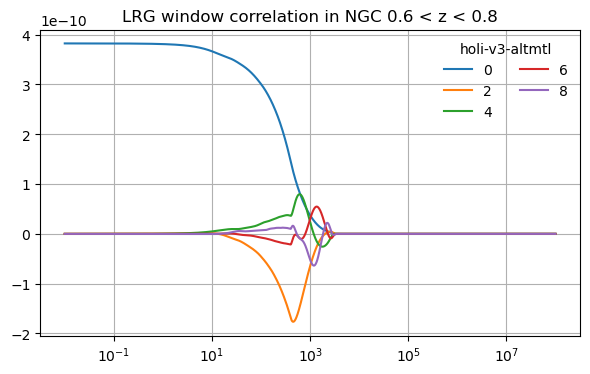

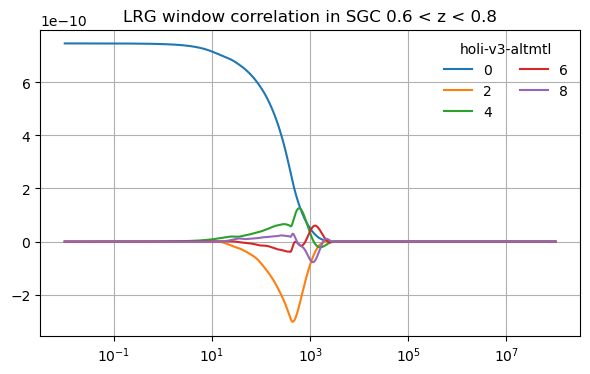


CPU times: user 962 ms, sys: 107 ms, total: 1.07 s
Wall time: 1.07 s


In [21]:
%%time
# now plot windows
versions = ['holi-v3-altmtl', 'glam-uchuu-v2-altmtl', 'abacus-hf-dr2-v2-altmtl']
for version in versions[:1]:
    for tracer in tracers:
        for region in ['NGC','SGC']:
            # zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
            ncols  = len(zranges)
            fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4), sharex='col')
            for iz, zrange in enumerate(zranges):  
                if ncols==1: ax = axes
                else: ax = axes[iz]
                ax.set_title(f'{tracer} window correlation in {region} {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        
                fn = tools.get_stats_fn(stats_dir=stats_dir, kind='window_covariance_mesh2_correlation', version=version, tracer=tracer, 
                                        project=project, zrange=zrange, region=region, weight=weight, imock=ref_imock[version])
                correlation = types.read(fn).get(types='WW')
                correlation = next(iter(correlation))
                ells_ = correlation.ells
                for i,pole in enumerate(correlation):
                    ax.plot(s:=pole.coords('s'), pole.value(), label=ells_[i])
                ax.legend(frameon=False, ncol=2, title=version)
                ax.set_xscale('log')
                ax.grid(True)
                
            plt.tight_layout()
            basename = f'{version}_window_mesh2_{version}_{tracer}_{region}.{ext}'
            fig.savefig(plot_dir / tracer / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()
            print()
